In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io

In [4]:
colores = {
   0: '#C72A66',     # Frambuesa oscuro (test-model_082337)
   1: '#B16A3C',      # Bronce / Marrón cobrizo (test-model_080952)
   2: '#1E8675',   # Verde azulado / Teal (test-model_060949)
   3: "#7D1485"  # Fucsia vibrante (test-model_051324)
}

153


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_27460\2981846589.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


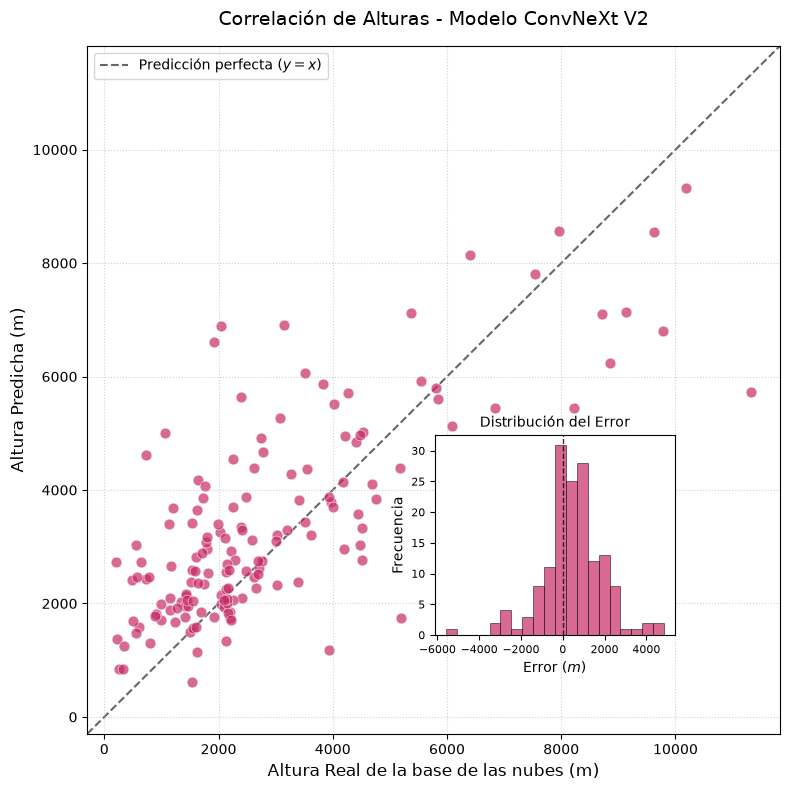

In [6]:
df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\results\test-model_121723\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

# Limpiamos posibles espacios en blanco
df.columns = df.columns.str.strip()

real = df['Real (m)']
print(len(real))
predicho = df['Predicho (m)']

error_con_signo = predicho - real #el error del archivo .txt es el absoluto (sin signo)

# 2. Configuración general de la figura
fig, ax = plt.subplots(figsize=(8, 8))

# --- GRÁFICO PRINCIPAL (PARITY PLOT) ---
# Usamos el color fucsia vibrante de tu diccionario para el ConvNeXt V2, por ejemplo
ax.scatter(real, predicho, alpha=0.7, color=colores[0], edgecolors='white', linewidth=0.5, s=60)

# Calculamos los límites para dibujar la línea ideal y=x
min_val = min(real.min(), predicho.min()) - 500
max_val = max(real.max(), predicho.max()) + 500

# Dibujamos la línea de predicción perfecta
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, zorder=0, label='Predicción perfecta ($y=x$)')

# Ajustamos los límites de los ejes para que el gráfico sea cuadrado
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# Etiquetas y diseño del gráfico principal
ax.set_xlabel('Altura Real de la base de las nubes (m)', fontsize=12)
ax.set_ylabel('Altura Predicha (m)', fontsize=12)
ax.set_title('Correlación de Alturas - Modelo ConvNeXt V2', fontsize=14, pad=15)
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO INCRUSTADO (HISTOGRAMA DEL ERROR) ---
# La función add_axes toma [izquierda, abajo, ancho, alto] en coordenadas relativas (de 0 a 1)
# Lo colocamos abajo a la derecha, donde suele haber espacio vacío en los Parity Plots
ax_hist = fig.add_axes([0.55, 0.20, 0.30, 0.25])

ax_hist.hist(error_con_signo, bins=20, color=colores[0], alpha=0.7, edgecolor='black', linewidth=0.5)

# Línea vertical en el 0 para marcar el error nulo
ax_hist.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.8)

# Etiquetas del histograma
ax_hist.set_xlabel('Error ($m$)', fontsize=10)
ax_hist.set_ylabel('Frecuencia', fontsize=10)
ax_hist.set_title('Distribución del Error', fontsize=10)
ax_hist.tick_params(axis='both', which='major', labelsize=8)

# 3. Guardar y mostrar
plt.tight_layout()
# plt.savefig('parity_plot_convnext.png', dpi=300, bbox_inches='tight')
plt.show()